##***Task 5: Personal Loan Acceptance Prediction***

##Overview
In this task, we use the Bank Marketing Dataset to predict whether a customer will accept a personal loan offer. We perform in-depth exploratory data analysis, then train a Decision Tree classifier to identify which customer segments are most likely to respond positively. Model performance is evaluated using accuracy, confusion matrix, and feature importance.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [8]:
df = pd.read_csv('bank-additional-full.csv', sep=';')  # UCI dataset uses semicolon
print(df.head())
print(df['y'].value_counts())  # Target: yes/no

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

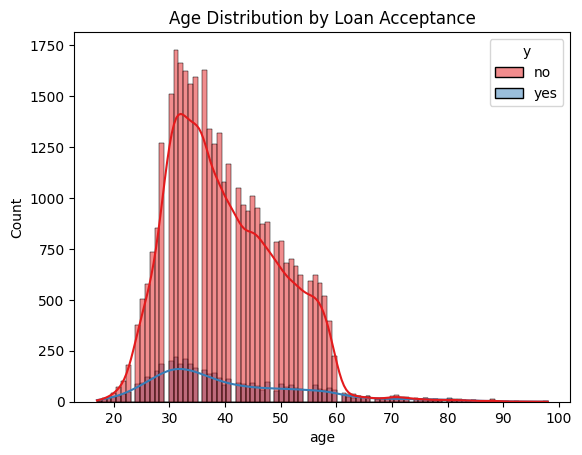

In [10]:
# Age distribution by loan acceptance
sns.histplot(data=df, x='age', hue='y', kde=True, palette='Set1')
plt.title("Age Distribution by Loan Acceptance")
plt.show()



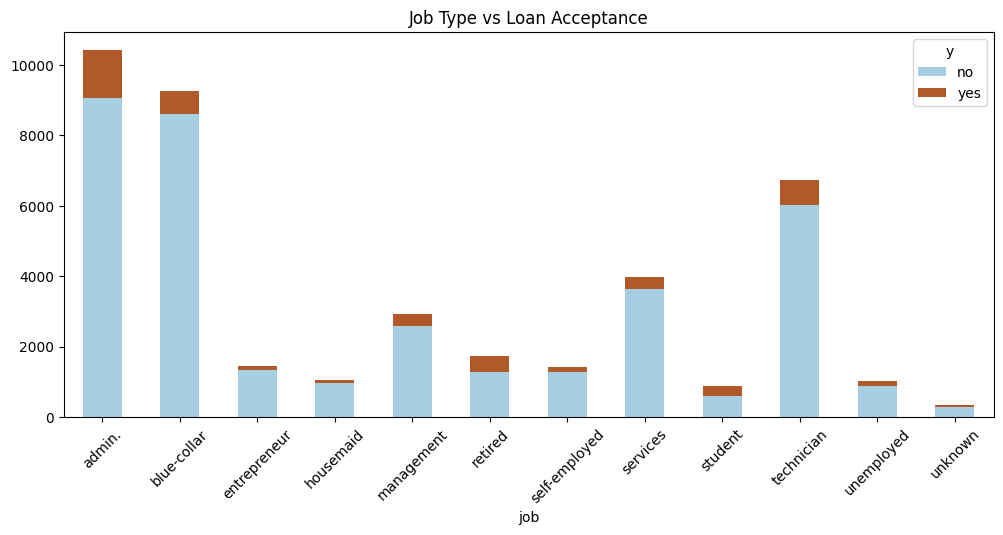

In [12]:
# Job type vs loan acceptance (unique bar chart)
job_target = df.groupby(['job','y']).size().unstack()
job_target.plot(kind='bar', stacked=True, figsize=(12,5), colormap='Paired')
plt.title("Job Type vs Loan Acceptance")
plt.xticks(rotation=45)
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 91.49%


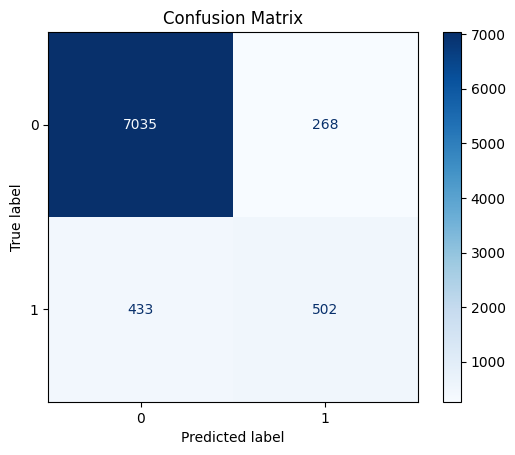

In [17]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

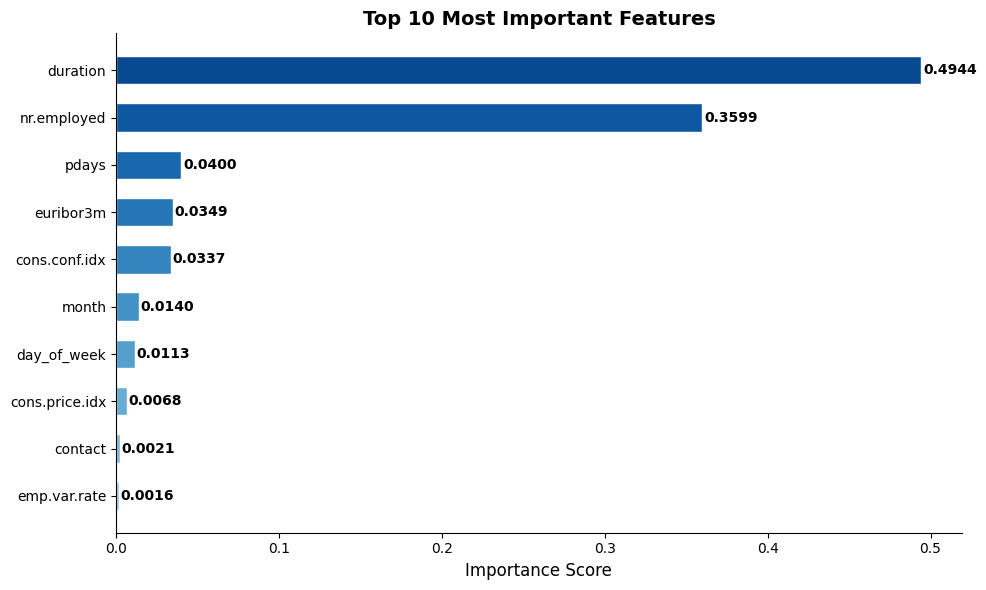

In [32]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features)))
bars = ax.barh(top_features.index, top_features.values,
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, top_features.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Top 10 Most Important Features", fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

**Visualize customer demographics and behaviors to uncover patterns that influence loan acceptance. Each chart is designed for clarity and business readability.**

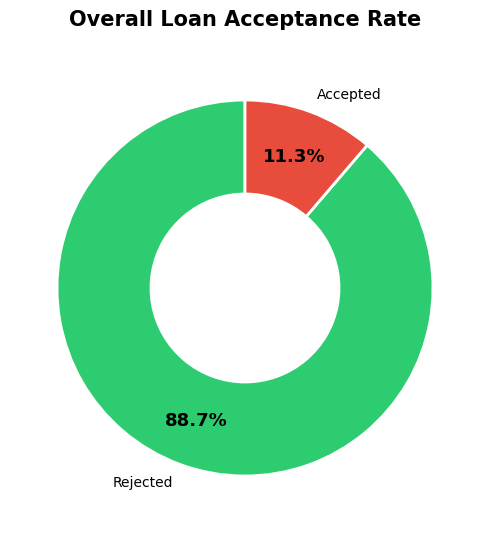

In [19]:
# Overall acceptance rate — clean donut chart
counts = df['y'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(5, 7))
wedges, texts, autotexts = ax.pie(
    counts, labels=['Rejected', 'Accepted'],
    autopct='%1.1f%%', startangle=90,
    colors=colors, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

ax.set_title("Overall Loan Acceptance Rate", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

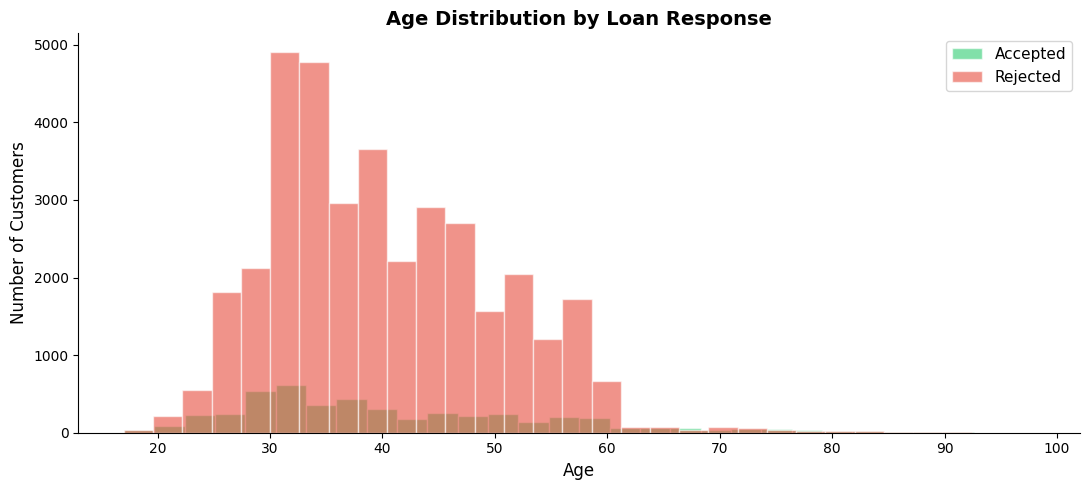

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
for label, color in zip(['yes', 'no'], ['#2ecc71', '#e74c3c']):
    subset = df[df['y'] == label]['age']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=f"{'Accepted' if label=='yes' else 'Rejected'}", edgecolor='white')

ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)
ax.set_title("Age Distribution by Loan Response", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

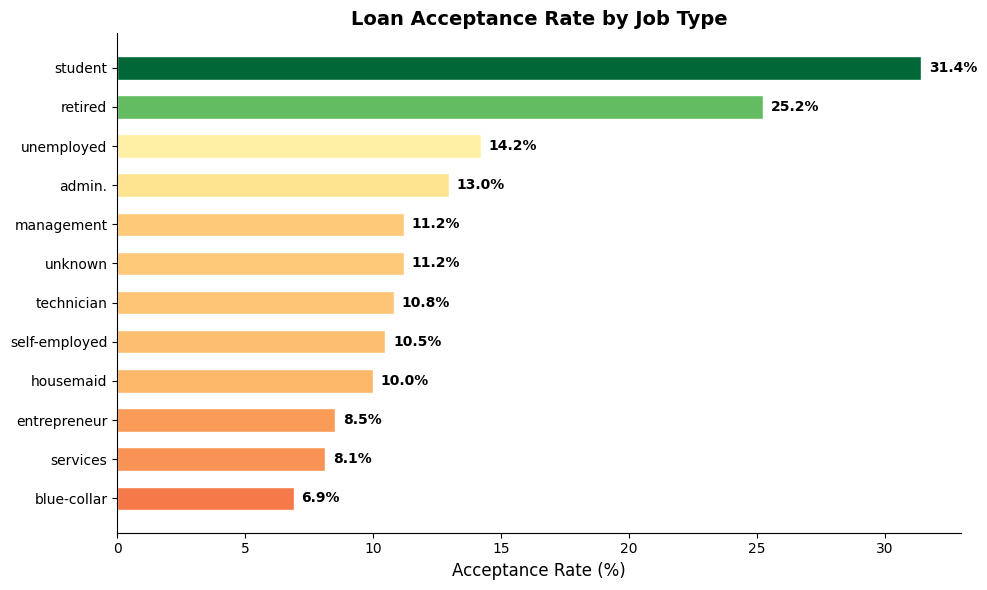

In [25]:
job_rate = (df.groupby('job')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(job_rate.index, job_rate.values,
               color=plt.cm.RdYlGn(job_rate.values / job_rate.values.max()),
               edgecolor='white', height=0.6)

for bar, val in zip(bars, job_rate.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Acceptance Rate (%)", fontsize=12)
ax.set_title("Loan Acceptance Rate by Job Type", fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

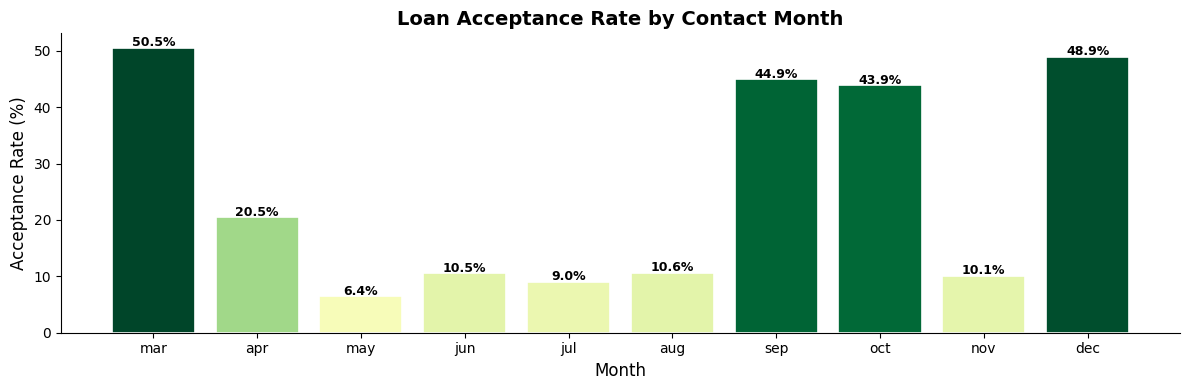

In [30]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_rate = (df.groupby('month')['y']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reindex(month_order)
               .reset_index())
month_rate.columns = ['month', 'acceptance_rate']

fig, ax = plt.subplots(figsize=(12, 4))
colors_month = plt.cm.YlGn(month_rate['acceptance_rate'] / month_rate['acceptance_rate'].max())
bars = ax.bar(month_rate['month'], month_rate['acceptance_rate'],
              color=colors_month, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, month_rate['acceptance_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Acceptance Rate (%)", fontsize=12)
ax.set_title("Loan Acceptance Rate by Contact Month", fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()